Na simulação usamos Temperatura e Magnetização com unidades adimensionais, para trazer os valores para a realidade utilizamos:

Para temperatura, em K:

$$T_{\text{SI}} = T_{\text{simulação}} \left( \frac{J}{k_B} \right)$$

Onde: 
$J$: é energia de interação de troca, que depende do material
$k_B$: é a constante de Boltzmann, $k_B \approx 1.38 \times 10^{-23}$ J/K.

Para a magnetização em A/m:

$$M_{\text{SI}} = M_{\text{simulação}} \left( \frac{\mu}{a^3} \right)$$

Onde:
$\mu$: é o momento magnético de um único átomo (geralmente dado em Magnetons de Bohr, onde $1 \, \mu_B \approx 9.274 \times 10^{-24}$ J/T)

$a^3$: é o volume da célula unitária (o espaço tridimensional que cada spin ocupa na rede de átomos).



In [72]:
import numpy as np
import matplotlib.pyplot as plt

def inicializar_grid(N):
    """Inicializa a matriz de spins
    
    N: Dimensão da Matriz
    
    Retorna um np.array NxN com os spins aleatórios"""
    rng = np.random.default_rng()
    return rng.choice([1, -1], size=(N, N))

In [ ]:


def ising(N, sweeps, T, termalizacao, J=1.0):
    """
    N: dimensão da grid
    sweeps: Quantas vezes foram realizadas NxN tentativas de inversão de spin, consideramos nossa medida de tempo.
    T: Temperatura.
    J: Constante de acoplamento.
    termalização: Número inicial de sweeps descartados para garantir que o sistema atinja o equilíbrio térmico antes da coleta de dados para a média.

    """
    rng = np.random.default_rng()
    grid = inicializar_grid(N)
    
    grid_evolucao = []
    magnetizacao_evolucao = [] 
    magnetizacao_equilibrio = []
    

    for sweep in range(sweeps):
        #Em cada sweep, tentamos trocar o valor de N*N spins aleatórios
        for _ in range(N * N):
            i = rng.integers(0, N)
            j = rng.integers(0, N)
            spin = grid[i, j]
            
            vizinhos = (grid[(i + 1) % N, j] + 
                        grid[(i - 1) % N, j] + 
                        grid[i, (j + 1) % N] + 
                        grid[i, (j - 1) % N])
            
            dE = 2 * J * spin * vizinhos
            
            # Critério de Metropolis
            if dE <= 0 or rng.random() < np.exp(-dE / T):
                grid[i, j] *= -1
                
        #Coleta de dados (uma vez por sweep)
        mag_atual = np.abs(np.mean(grid))
        magnetizacao_evolucao.append(mag_atual)

        if sweep % 10 == 0:
            grid_evolucao.append(grid.copy())
        
        #Só guardamos na média se já tiver passado do tempo de termalização
        if sweep >= termalizacao:
            magnetizacao_equilibrio.append(mag_atual)
            
    return grid,grid_evolucao, magnetizacao_evolucao, np.mean(magnetizacao_equilibrio)



SIMULAÇÕES:

Considerando uma grid 20x20, com 501 sweeps e Temperatura 1.5.

In [74]:
N = 20
sweeps = 501
T = 1.5
termalizacao = 100

grid,grid_evolucao, mag, m_mag = ising(N, sweeps, T, termalizacao)

Estados dos Spins:

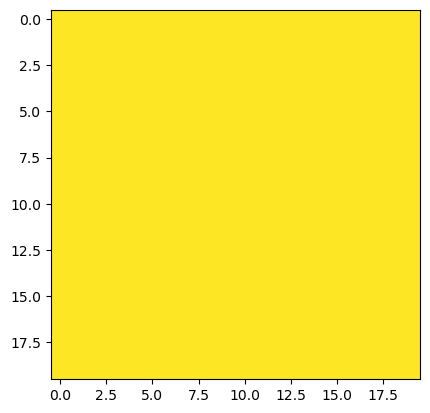

In [75]:
plt.imshow(grid,vmin=-1, vmax=1)

In [76]:
#animação mostrando a organização dos spins em função dos sweeps.

from matplotlib.animation import FuncAnimation
from IPython.display import HTML

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_title(f"Modelo de Ising 2D (T = {T})")


im = ax.imshow(grid_evolucao[0],vmin=-1, vmax=1, animated=True)
ax.axis('off')  


def atualizar(frame):
    
    im.set_data(grid_evolucao[frame])
    return [im]
ani = FuncAnimation(fig, atualizar, frames=len(grid_evolucao), interval=50, blit=True)
plt.close()

HTML(ani.to_jshtml())

Magnetismo médio: 0.9872443890274314


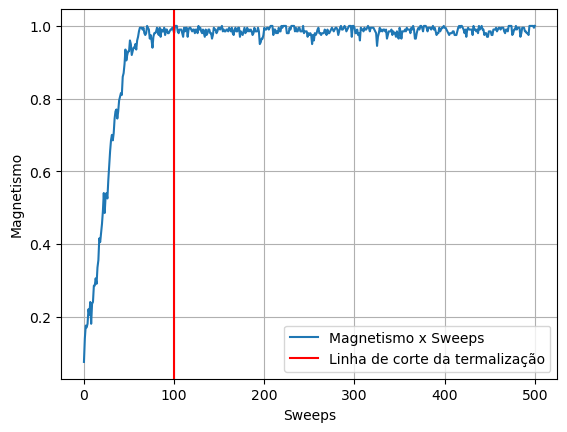

In [77]:

plt.plot(mag, label = "Magnetismo x Sweeps")
plt.ylabel("Magnetismo")
plt.xlabel("Sweeps")
plt.axvline(x=termalizacao, color='red', label="Linha de corte da termalização")
plt.legend()
plt.grid()

print(f"Magnetismo médio: {m_mag}")

Como a temperatura pode influenciar na magnetização:

In [ ]:
T = np.linspace(1.0,4.0,31)
N = 20
sweeps = 501
termalizacao = 100
 

mag_media = []
grid_temp = []
for t in T:
    grid,grid_evolucao, mag, m_mag = ising(N, sweeps, t, termalizacao)
    mag_media.append(m_mag)
    if t % 1 == 0:
        grid_temp.append(grid.copy())


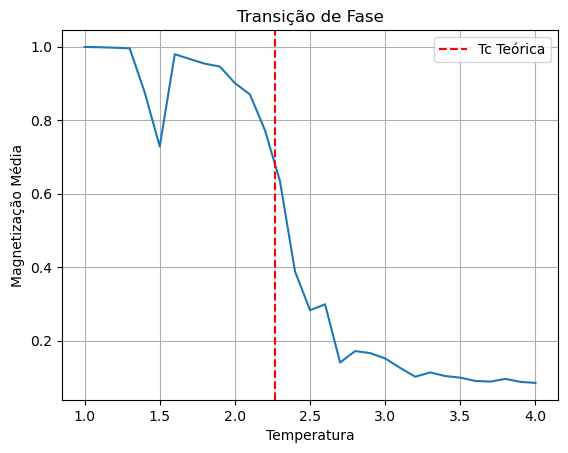

In [ ]:
plt.plot(T, mag_media)
plt.xlabel("Temperatura")
plt.ylabel("Magnetização Média")
plt.axvline(x=2.269, color='red', linestyle='--', label="Tc Teórica")
plt.title("Transição de Fase")
plt.legend()
plt.grid()
plt.show()

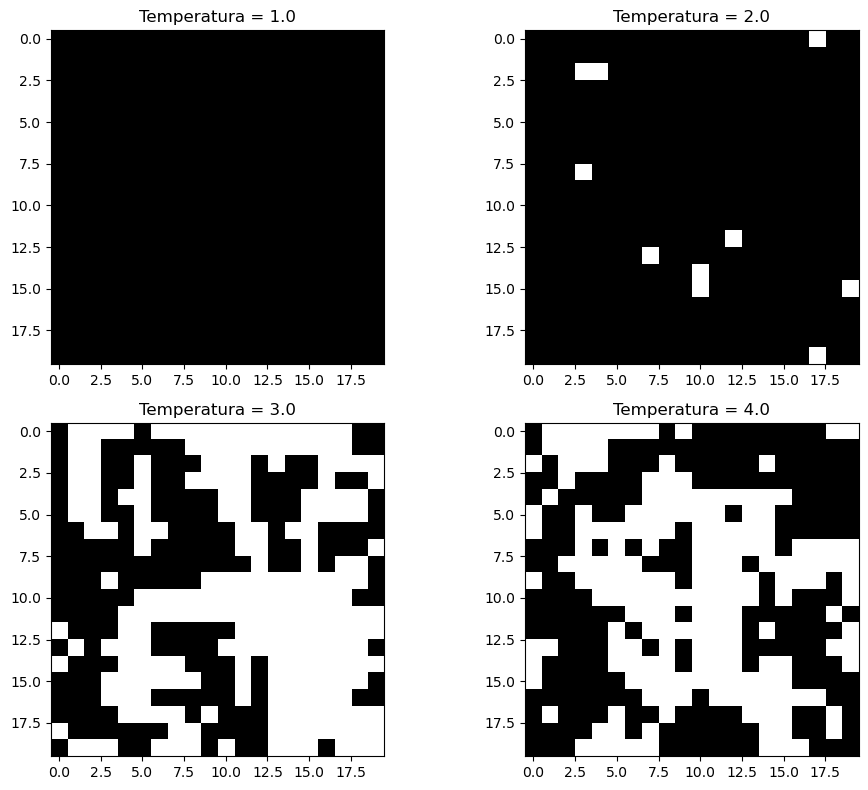

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

parametros_imagem = {'vmin': -1, 'vmax': 1, 'cmap': 'gray'}

axs[0, 0].imshow(grid_temp[0], **parametros_imagem)
axs[0, 0].set_title("Temperatura = 1.0")

axs[0, 1].imshow(grid_temp[1], **parametros_imagem)
axs[0, 1].set_title("Temperatura = 2.0")

axs[1, 0].imshow(grid_temp[2], **parametros_imagem)
axs[1, 0].set_title("Temperatura = 3.0")

axs[1, 1].imshow(grid_temp[3], **parametros_imagem)
axs[1, 1].set_title("Temperatura = 4.0")

plt.tight_layout()
plt.show()